<a href="https://colab.research.google.com/github/kilianodonell-cmd/Durban/blob/main/Polygon_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── Install packages ─────────────────────────────────────────
!pip install folium rasterio geopandas numpy matplotlib -q


In [2]:

# ── Mount Google Drive ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# CELL 1 — Setup
# Polygon Tool — Street Address Selection
# Mzinyati Stream Catchment, eThekwini Municipality
#
# Workflow:
#   1. Load AOI, boundary, street address points
#   2. Display background image + addresses on an interactive map
#   3. Pick point IDs from the map
#   4. Create + save a polygon from those points
# ============================================================
import os, json, numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import folium

CONFIG_PATH = '/content/drive/MyDrive/Durban/outputs/field_map_config.json'
DATA_ROOT   = '/content/drive/MyDrive/Durban/data'

with open(CONFIG_PATH) as f:
    config = json.load(f)

OUTPUT_ROOT         = config['OUTPUT_ROOT']
TARGET_CRS          = config['TARGET_CRS']
Street_Address_PATH = os.path.join(DATA_ROOT, 'reference', 'Street_Address_-3553917709285038578.gpkg')
BOUNDARY_PATH       = os.path.join(DATA_ROOT, 'reference', 'eThekwini_Municipal_Boundary_-6866066624922810567.gpkg')

# ── Background image (adjust path if needed) ──────────────────
IMG_PATH = "/content/drive/MyDrive/Durban/data/group_c_socioeconomic/Prime_Investment_Corridor_p244.jpg"
img      = mpimg.imread(IMG_PATH)

print("Config loaded.")
print(f"  Output root: {OUTPUT_ROOT}")


Config loaded.
  Output root: /content/drive/MyDrive/Durban/outputs


In [4]:
# ============================================================
# CELL 2 — Load AOI, boundary and street addresses
# ============================================================
print("Loading layers...")

catchments = gpd.read_file(config['CATCHMENTS_PATH']).to_crs(TARGET_CRS)
boundary   = gpd.read_file(BOUNDARY_PATH).to_crs(TARGET_CRS)

aoi = (catchments[catchments[config['AOI_FIELD']] == config['AOI_VALUE']]
       .dissolve().reset_index(drop=True))

street_address        = gpd.read_file(Street_Address_PATH).to_crs(TARGET_CRS)
street_address_in_aoi = gpd.clip(street_address, aoi)

aoi_wgs84    = aoi.to_crs("EPSG:4326")
bounds_wgs84 = aoi_wgs84.total_bounds          # minx, miny, maxx, maxy
centre       = [(bounds_wgs84[1] + bounds_wgs84[3]) / 2,
                (bounds_wgs84[0] + bounds_wgs84[2]) / 2]

print(f"  AOI CRS:                {aoi.crs}")
print(f"  Street addresses total: {len(street_address):,}")
print(f"  Inside AOI:             {len(street_address_in_aoi):,}")
print(f"  Map centre:             {centre}")


Loading layers...


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column created_da, 2013-10-23T00:00:00.0Z, successfully parsed
  return ogr_read(


  AOI CRS:                EPSG:32736
  Street addresses total: 6,559
  Inside AOI:             60
  Map centre:             [np.float64(-29.66638580976899), np.float64(30.891268429684253)]


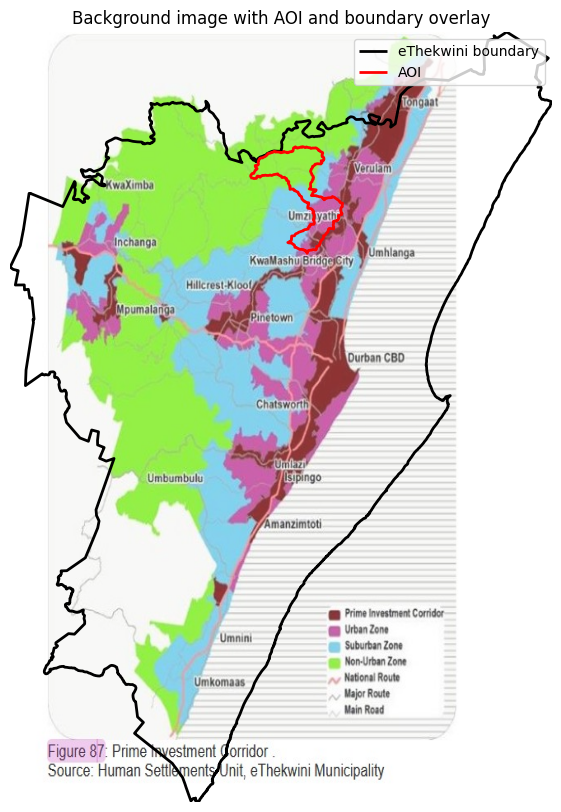

In [5]:
# ============================================================
# CELL 3 — Background image with AOI overlay
# Quick visual check that the image aligns with the AOI.
# ============================================================
bounds = boundary.total_bounds   # minx, miny, maxx, maxy

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img, extent=[bounds[0], bounds[2], bounds[1], bounds[3]], alpha=0.8)
boundary.boundary.plot(ax=ax, color="black", linewidth=2, label="eThekwini boundary")
aoi.boundary.plot(ax=ax, color="red",   linewidth=2, label="AOI")
ax.legend()
ax.set_title("Background image with AOI and boundary overlay")
ax.set_axis_off()
plt.show()


In [6]:
# ============================================================
# CELL — Interactive Folium map with point IDs
# ============================================================

import folium

# convert to WGS84 for web map
aoi_wgs84 = aoi.to_crs("EPSG:4326")
street_wgs84 = street_address_in_aoi.to_crs("EPSG:4326")

# map centre
minx, miny, maxx, maxy = aoi_wgs84.total_bounds
centre = [(miny + maxy) / 2, (minx + maxx) / 2]

m = folium.Map(location=centre, zoom_start=15, tiles="OpenStreetMap")

# AOI boundary
folium.GeoJson(
    aoi_wgs84,
    name="AOI",
    style_function=lambda x: {
        "color": "red",
        "weight": 2,
        "fillOpacity": 0
    }
).add_to(m)

# add points with index in popup
for idx, row in street_wgs84.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color="blue",
        fill=True,
        fill_opacity=0.8,
        popup=f"Index: {idx}"
    ).add_to(m)

m

Selected 10 points: [1611, 3795, 1720, 5303, 2927, 3787, 2511, 1043, 688, 3166]


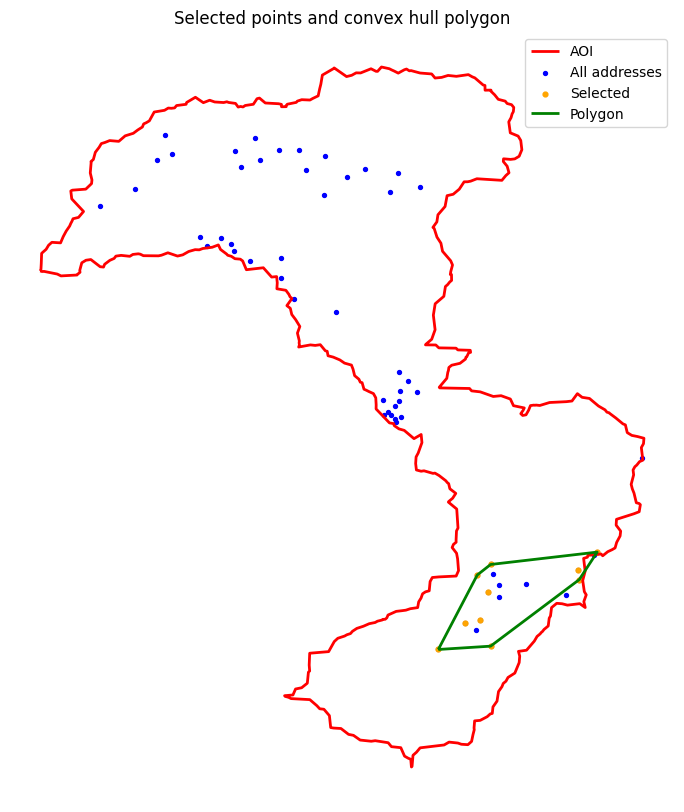


  Polygon saved → /content/drive/MyDrive/Durban/outputs/selected_polygon.gpkg


In [7]:
# ============================================================
# CELL 5 — Create polygon from selected point IDs
# ============================================================
# 1. Run CELL 4 (interactive map) to find your point IDs
# 2. Paste the IDs you want below, then run this cell

selected_indices = [1611, 3795, 1720, 5303, 2927, 3787, 2511, 1043, 688, 3166]
# ↑ replace with your chosen IDs from the map

print(f"Selected {len(selected_indices)} points: {selected_indices}")

selected_points = street_address_in_aoi.loc[selected_indices].copy()
polygon         = selected_points.union_all().convex_hull

polygon_gdf = gpd.GeoDataFrame(
    {"name": ["selected_polygon"]},
    geometry=[polygon],
    crs=street_address_in_aoi.crs
)

out_poly = "/content/drive/MyDrive/Durban/outputs/selected_polygon.gpkg"
polygon_gdf.to_file(out_poly, driver="GPKG")

# ── Visual check ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
aoi.boundary.plot(ax=ax,         color="red",   linewidth=2, label="AOI")
street_address_in_aoi.plot(ax=ax, color="blue", markersize=8, label="All addresses")
selected_points.plot(ax=ax,      color="orange",markersize=12,label="Selected")
polygon_gdf.boundary.plot(ax=ax, color="green", linewidth=2, label="Polygon")
ax.legend()
ax.set_title("Selected points and convex hull polygon")
ax.set_axis_off()
plt.show()

print(f"\n  Polygon saved → {out_poly}")


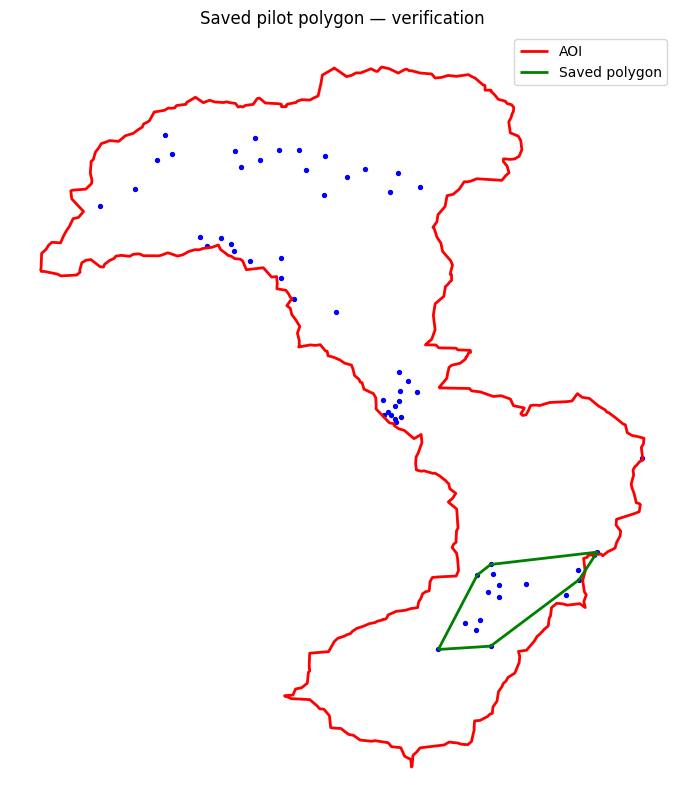

  Polygon geometry type: Polygon
  CRS: EPSG:32736


In [8]:
# ============================================================
# CELL 6 — Reload and verify saved polygon
# ============================================================
pilot_check = gpd.read_file("/content/drive/MyDrive/Durban/outputs/selected_polygon.gpkg")

fig, ax = plt.subplots(figsize=(10, 10))
aoi.boundary.plot(ax=ax,            color="red",   linewidth=2, label="AOI")
street_address_in_aoi.plot(ax=ax,   color="blue",  markersize=8)
pilot_check.boundary.plot(ax=ax,    color="green", linewidth=2, label="Saved polygon")
ax.legend()
ax.set_title("Saved pilot polygon — verification")
ax.set_axis_off()
plt.show()

print(f"  Polygon geometry type: {pilot_check.geometry.geom_type.values[0]}")
print(f"  CRS: {pilot_check.crs}")
